=== DATASET HOUSE PRICES ===
Train : (1460, 81)
Test  : (1459, 80)

=== APERÇU ===
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD         Normal     208500  
1   2007        WD         Normal     181500  
2   2008        WD         Normal     223500  

[3 rows x 81 columns]

=== TARGET (SalePrice) ===
count      1460.000000
mean     180921.195890
std       

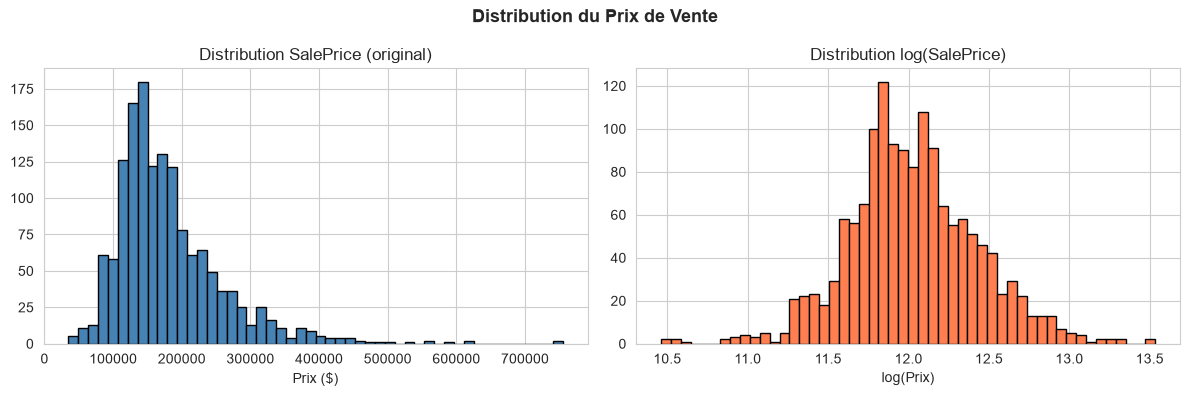


→ On utilise log(SalePrice) pour normaliser la distribution


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Charger les données
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("=== DATASET HOUSE PRICES ===")
print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")

print("\n=== APERÇU ===")
print(train.head(3))

print("\n=== TARGET (SalePrice) ===")
print(train["SalePrice"].describe())

print("\n=== VALEURS MANQUANTES TOP 15 ===")
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.head(15))

# Visualisation du target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train["SalePrice"], bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution SalePrice (original)")
axes[0].set_xlabel("Prix ($)")

axes[1].hist(np.log1p(train["SalePrice"]), bins=50, color="coral", edgecolor="black")
axes[1].set_title("Distribution log(SalePrice)")
axes[1].set_xlabel("log(Prix)")

plt.suptitle("Distribution du Prix de Vente", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n→ On utilise log(SalePrice) pour normaliser la distribution")

In [2]:
# Combiner train et test pour preprocessing cohérent
all_data = pd.concat([train.drop("SalePrice", axis=1), test], axis=0)
all_data = all_data.reset_index(drop=True)

print(f"Shape combiné : {all_data.shape}")

# 1. Colonnes avec trop de NaN → supprimer
cols_drop = ["PoolQC", "MiscFeature", "Alley", "Fence"]
all_data = all_data.drop(cols_drop, axis=1)

# 2. Features numériques → imputer avec médiane
num_cols = all_data.select_dtypes(include=[np.number]).columns
all_data[num_cols] = all_data[num_cols].fillna(all_data[num_cols].median())

# 3. Features catégorielles → imputer avec "None"
cat_cols = all_data.select_dtypes(include=["object"]).columns
all_data[cat_cols] = all_data[cat_cols].fillna("None")

print(f"NaN restants : {all_data.isnull().sum().sum()}")

# 4. Feature Engineering
all_data["TotalSF"] = (all_data["TotalBsmtSF"] + 
                        all_data["1stFlrSF"] + 
                        all_data["2ndFlrSF"])

all_data["TotalBath"] = (all_data["FullBath"] + 
                          0.5 * all_data["HalfBath"] +
                          all_data["BsmtFullBath"] + 
                          0.5 * all_data["BsmtHalfBath"])

all_data["HouseAge"] = all_data["YrSold"] - all_data["YearBuilt"]
all_data["RenovAge"] = all_data["YrSold"] - all_data["YearRemodAdd"]
all_data["IsNew"] = (all_data["HouseAge"] <= 0).astype(int)

# 5. Encodage One-Hot
all_data = pd.get_dummies(all_data, drop_first=True)
print(f"Shape après encodage : {all_data.shape}")

# 6. Séparer train et test
n_train = len(train)
X = all_data[:n_train]
X_test_final = all_data[n_train:]
y = np.log1p(train["SalePrice"])

print(f"\nX train shape : {X.shape}")
print(f"X test shape  : {X_test_final.shape}")
print(f"y shape       : {y.shape}")

Shape combiné : (2919, 80)
NaN restants : 0
Shape après encodage : (2919, 260)

X train shape : (1460, 260)
X test shape  : (1459, 260)
y shape       : (1460,)


=== COMPARAISON DES MODÈLES ===
(RMSE log — plus c'est bas, mieux c'est)

Ridge                → RMSE: 0.16057 ± 0.03421
Lasso                → RMSE: 0.16245 ± 0.03563
ElasticNet           → RMSE: 0.16825 ± 0.03572
Random Forest        → RMSE: 0.14360 ± 0.01871
Gradient Boosting    → RMSE: 0.13337 ± 0.01885
XGBoost              → RMSE: 0.13982 ± 0.01876


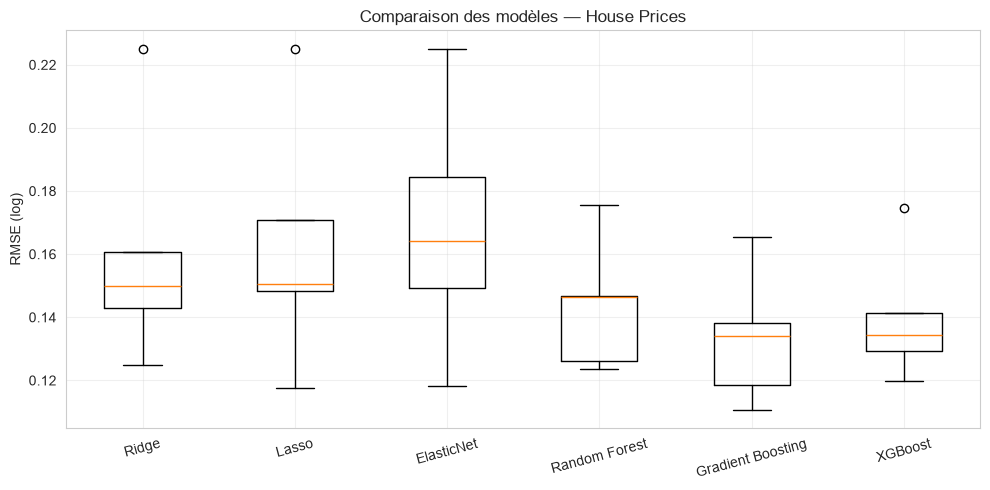


✅ Meilleur modèle : Gradient Boosting
   RMSE : 0.13337


In [3]:
# Cross-validation avec RMSE log
def rmse_cv(model, X, y, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = np.sqrt(-cross_val_score(model, X, y, 
                                       scoring="neg_mean_squared_error", cv=kf))
    return scores

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

# Modèles
modeles = {
    "Ridge":              Ridge(alpha=10),
    "Lasso":              Lasso(alpha=0.001),
    "ElasticNet":         ElasticNet(alpha=0.001, l1_ratio=0.5),
    "Random Forest":      RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting":  GradientBoostingRegressor(n_estimators=200, 
                                                     learning_rate=0.05,
                                                     random_state=42),
    "XGBoost":            xgb.XGBRegressor(n_estimators=200, 
                                            learning_rate=0.05,
                                            random_state=42,
                                            verbosity=0)
}

print("=== COMPARAISON DES MODÈLES ===")
print("(RMSE log — plus c'est bas, mieux c'est)\n")

resultats = {}
for nom, model in modeles.items():
    if nom in ["Ridge", "Lasso", "ElasticNet"]:
        scores = rmse_cv(model, X_scaled, y)
    else:
        scores = rmse_cv(model, X, y)
    resultats[nom] = scores
    print(f"{nom:20s} → RMSE: {scores.mean():.5f} ± {scores.std():.5f}")

# Visualisation
plt.figure(figsize=(10, 5))
plt.boxplot(resultats.values(), tick_labels=resultats.keys())
plt.title("Comparaison des modèles — House Prices")
plt.ylabel("RMSE (log)")
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best = min(resultats, key=lambda k: resultats[k].mean())
print(f"\n✅ Meilleur modèle : {best}")
print(f"   RMSE : {resultats[best].mean():.5f}")

In [4]:
# ENSEMBLE — combiner plusieurs modèles pour de meilleures performances
from sklearn.base import BaseEstimator, RegressorMixin

class EnsembleModel(BaseEstimator, RegressorMixin):
    def __init__(self, models, weights=None):
        self.models = models
        self.weights = weights or [1/len(models)] * len(models)
    
    def fit(self, X, y):
        for model in self.models:
            model.fit(X, y)
        return self
    
    def predict(self, X):
        preds = np.column_stack([m.predict(X) for m in self.models])
        return np.average(preds, axis=1, weights=self.weights)

# Entraîner les meilleurs modèles
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                max_depth=4, random_state=42)
xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05,
                               random_state=42, verbosity=0)
ridge = Ridge(alpha=10)

# Ensemble avec poids
ensemble = EnsembleModel(
    models=[gb, xgb_model, ridge],
    weights=[0.4, 0.4, 0.2]
)

# CV de l'ensemble
print("=== ENSEMBLE MODEL ===")
# Entraîner séparément pour CV
gb_scores = rmse_cv(gb, X, y)
xgb_scores = rmse_cv(xgb_model, X, y)
ridge_scores = rmse_cv(ridge, X_scaled, y)

print(f"GB    RMSE : {gb_scores.mean():.5f}")
print(f"XGB   RMSE : {xgb_scores.mean():.5f}")
print(f"Ridge RMSE : {ridge_scores.mean():.5f}")

# Entraîner l'ensemble sur tout le train
gb.fit(X, y)
xgb_model.fit(X, y)
ridge.fit(X_scaled, y)

# Prédictions ensemble
pred_gb    = gb.predict(X_test_final)
pred_xgb   = xgb_model.predict(X_test_final)
pred_ridge = ridge.predict(X_test_scaled)

pred_ensemble = 0.4*pred_gb + 0.4*pred_xgb + 0.2*pred_ridge

# Convertir log → prix réel
final_predictions = np.expm1(pred_ensemble)

# Soumission
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": final_predictions
})
submission.to_csv("submission.csv", index=False)

print(f"\n✅ Soumission créée !")
print(f"Prix moyen prédit : ${final_predictions.mean():,.0f}")
print(f"Prix min prédit   : ${final_predictions.min():,.0f}")
print(f"Prix max prédit   : ${final_predictions.max():,.0f}")
print(submission.head(10))

=== ENSEMBLE MODEL ===
GB    RMSE : 0.13324
XGB   RMSE : 0.13937
Ridge RMSE : 0.16057

✅ Soumission créée !
Prix moyen prédit : $175,796
Prix min prédit   : $49,038
Prix max prédit   : $563,981
     Id      SalePrice
0  1461  121719.995910
1  1462  158245.735066
2  1463  178331.194396
3  1464  189896.910376
4  1465  184142.352771
5  1466  172492.762095
6  1467  180683.797338
7  1468  168657.821835
8  1469  186065.279767
9  1470  121752.923695
